In [1]:
import seaborn as sns

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "k",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif"}
sns.set_theme(context = "notebook", style="ticks", rc=custom_params) 

# Extraction functions

In [2]:
from typing import List, Tuple
import numpy as np
import parameters
import pandas as pd
from pathlib import Path

def parse_config(path: str) -> Tuple[List[np.ndarray], int]:
    """
    Parses .config files containing trajectories of particlrs in suspension at each time step.
    Arguments : 
        path, the path to the config file.
    Returns : 
        frames, lists of arrays of positions per time step.
        n_expected, the number of expected separate trajectorires.
    """
    frames: List[np.ndarray] = []
    n_expected = None

    with open(path, "r", encoding="utf-8") as f:
        lines = (ln.strip() for ln in f)
        while True:
            for ln in lines:
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) == 1 and parts[0].lstrip("-").isdigit():
                    n = int(parts[0])
                    if n <= 0:
                        raise ValueError(f"Invalid particle count: {n}")
                    if n_expected is None:
                        n_expected = n
                    elif n_expected != n:
                        raise ValueError(f"Inconsistent particle count: {n} (expected {n_expected})")
                    break
                else:
                    raise ValueError(f"Expected particle count line, got: {ln}")
            else:
                break 

            xyz = []
            for _ in range(n):
                try:
                    ln = next(lines).strip()
                except StopIteration:
                    raise ValueError("Unexpected EOF inside a timestep.")
                vals = ln.split()
                x, y, z = map(float, vals[:3])
                xyz.append((x, y, z))
            frames.append(np.asarray(xyz, dtype=float))
    return frames, n_expected





def frames_to_trajectories(frames: List[np.ndarray]) -> List[np.ndarray]:
    """
    Generates full trajectories from the frames.
    frames: list of arrays shaped (n,3) for each timestep.
    return: list of trajectories, each shaped (T,3), one per particle.
    """
    if not frames:
        raise ValueError("Where frames ???")
    n = frames[0].shape[0]
    arr = np.stack(frames, axis=0)  # (T, n, 3)
    return [arr[:, i, :] for i in range(n)]  # N [(T,3)]




3.9999999999999996e-05
180


# segmenting

In [3]:
def split_by_z_threshold(trajs: List[np.ndarray], z_threshold: float, inclusive: bool=True, min_len: int=3) -> List[List[np.ndarray]]:
    out: List[List[np.ndarray]] = []

    """
    Splits an individual xyz trajectory into segments based on a z criterion.
    Admits a minimal length to avoid micro trajectories polluting my stats.
    """
    for tr in trajs:
        z = tr[:, 2]
        active = (z <= z_threshold) if inclusive else (z < z_threshold)

        edges = np.flatnonzero(np.diff(np.r_[False, active, False]))
        starts, ends = edges[0::2], edges[1::2] 

        parts = []
        for s, e in zip(starts, ends):
            if e - s >= min_len:
                parts.append(tr[s:e].copy())
        out.append(parts)
    return out



# dedrifting

In [4]:
import numpy as np
from typing import List

def dedrift_shear_x(
    trajs: List[np.ndarray],
    dt: float,
    gamma_dot: float,
    return_full: bool = False
) -> List[np.ndarray]:
    
    """Calculates the mean drift a single particle will feel at a single time step and subtraxts it.
    Reconstructs the final trajectory without the shear. """

    if not trajs:
        return []

    out = []
    for tr in trajs:
        tr = np.asarray(tr, dtype=float)
        if tr.ndim != 2 or tr.shape[1] < 3:
            # if nothing to correct
            out.append(tr if return_full else tr[..., 0])
            continue

        x = tr[:, 0] #nothing to see along y
        z = tr[:, 2]

        if x.size < 2:
            # if nothing to diff/cumsum
            if return_full:
                out.append(tr.copy())
            else:
                out.append(x.copy())
            continue

        # Midpoint z between frames and dx
        z_mid  = 0.5 * (z[1:] + z[:-1])            
        dx     = x[1:] - x[:-1]                    
        shear_dx = gamma_dot * z_mid * dt          
        dx_corr  = dx - shear_dx                   # drift-removed step

        # Reconstruct corrected x by cumulative sum of corrected steps!
        x_corr = np.empty_like(x)
        x_corr[0]  = x[0]
        x_corr[1:] = x[0] + np.cumsum(dx_corr)

        if return_full:
            tr2 = tr.copy()
            tr2[:, 0] = x_corr
            out.append(tr2)
        else:
            out.append(x_corr)

    return out # 



In [5]:
def compute_average_msd(signal_list, dt):
    """Returns the MSD avg and std of a whole component."""
    lag_steps = np.hstack([np.arange(10**i, 10**(i+1), 10**i) for i in range(8)]).astype(int)
    if lag_steps.size == 0:
        return np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)

    def msd_fixed(x, lags):
        x = np.asarray(x, dtype=float)
        msd = np.empty(len(lags), dtype=float)
        for n, lag in enumerate(lags):
            # mean over valid pairs
            diffs = x[lag:] - x[:-lag]
            msd[n] = np.nanmean(diffs * diffs) if diffs.size else np.nan
        return msd

    all_msd = [msd_fixed(sig, lag_steps) for sig in signal_list]
    all_msd = np.vstack(all_msd)  # (Nsignals, Nlags)
    msd_avg = np.nanmean(all_msd, axis=0)
    msd_std = np.nanstd(all_msd, axis=0)
    return lag_steps * dt, msd_avg, msd_std


def compute_average_msd_nanpadding(signal_list, dt, min_coverage=0.3, max_decade=8):
    """
    Computes average MSD using geometric lag spacing, padding with NaN.
    Keeps lags where at least min_coverage fraction of trajectories contribute.

    Returns:
      taus (seconds), mean_msd, sem_msd
    """
    if len(signal_list) == 0:
        return np.array([]), np.array([]), np.array([])

    N = len(signal_list)

    lag_steps = np.hstack([np.arange(10**i, 10**(i+1), 10**i)
                           for i in range(max_decade)]).astype(int)
    
    def msd_fixed(x, lags):
        x = np.asarray(x, float)
        out = np.full(len(lags), np.nan)
        for j, lag in enumerate(lags):
            if lag < len(x):
                d = x[lag:] - x[:-lag]
                out[j] = np.nanmean(d * d)
        return out

    # per-trajectory MSDs
    all_msd = np.vstack([msd_fixed(s, lag_steps) for s in signal_list]) 

    # how many valid signals per lag
    valid_counts = np.sum(~np.isnan(all_msd), axis=0)

    # Keep only lags with sufficient support
    keep = valid_counts >= np.ceil(min_coverage * N)
    lag_steps = lag_steps[keep]
    all_msd = all_msd[:, keep]

    if lag_steps.size == 0:
        return np.array([]), np.array([]), np.array([])

    # NaNmean and SEM
    mean_msd = np.nanmean(all_msd, axis=0)
    std_msd  = np.nanstd(all_msd, axis=0)
    sem_msd  = std_msd / np.sqrt(valid_counts[keep])

    taus = lag_steps * dt
    return taus, mean_msd, sem_msd




# computing the MSD per z bin

In [6]:
def identify_trajectories_per_avg_height(signal_list, debye_height, evanescent_height, how_many_bins):
    """
    Maps bin index to a list of trajectories.
    """
    avg_heights = np.array([np.mean(traj[:, 2]) for traj in signal_list])
    
    bin_edges = np.linspace(debye_height, evanescent_height, how_many_bins + 1)

    bin_indices = np.digitize(avg_heights, bin_edges) - 1

    bin_indices = np.clip(bin_indices, 0, how_many_bins - 1)


    bins = {i: [] for i in range(how_many_bins)}

    for idx, traj in zip(bin_indices, signal_list):
        bins[idx].append(traj)

    return bins, bin_edges





In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def get_component_signal(tr, comp):
    if isinstance(tr, dict):
        return np.asarray(tr[comp], dtype=float)
    comp_idx = {'x': 0, 'y': 1, 'z': 2}[comp]
    tr = np.asarray(tr)
    if tr.ndim == 2 and tr.shape[1] >= comp_idx+1:
        return tr[:, comp_idx].astype(float)
    raise ValueError("Unrecognized trajectory format for get_component_signal")


def average_msd_per_bin(bins, bin_edges, comp, dt):
    bin_indices = sorted(bins.keys())
    centers_all = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    bin_centers_subset, taus_list, msd_mean, msd_sem = [], [], [], []

    for b in bin_indices:
        group = bins[b]
        if not group:
            continue

        sigs = [get_component_signal(tr, comp) for tr in group]
        taus, avg, std  = compute_average_msd_nanpadding(sigs, dt, min_coverage=0.3)

        if taus.size == 0:
            continue
        sem = std

        bin_centers_subset.append(centers_all[b])
        taus_list.append(taus)
        msd_mean.append(avg)
        msd_sem.append(sem)

    return np.array(bin_centers_subset), taus_list, msd_mean, msd_sem

def plot_msd_curves_per_bin(bin_centers, taus_list, msd_mean, msd_sem,
                                                  cmap_name="viridis", show_legend=False):


    fig, ax = plt.subplots()
    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(bin_centers), vmax=np.max(bin_centers))

    for c, taus, mean, sem in zip(bin_centers, taus_list, msd_mean, msd_sem):
        color = cmap(norm(c))
        label = f"h = {c:.2e}" if show_legend else "_nolabel_"

        ax.fill_between(taus, mean - sem, mean + sem,
                         color=color, alpha=.25)
        ax.plot(taus, mean, color=color, alpha=1, label=label)

    ax.set_xlabel("Lag time (s)")
    ax.set_ylabel("MSD")
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.tight_layout()

    # Colorbar showing bin altitude reference
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax = plt.gca(),  pad=0.01)
    cbar.set_label("z (um)")

    plt.show()
    
    return ax



def plot_all_segments(signals, comp, dt):
    plt.figure()
    for seg in signals:
        y = get_component_signal(seg, comp).astype(float)
        t = np.arange(len(y)) * dt
        plt.plot(t, y, alpha=0.8)

    plt.xlabel("Time (s)")
    plt.ylabel(f"{comp}(t)")
    plt.tight_layout()
    plt.show()




def _bin_centers_from_edges(edges):
    return 0.5 * (edges[:-1] + edges[1:])

def _segment_to_bin_map(bins):
    """Map each segment (by id) to its bin index."""
    seg2bin = {}
    for b_idx, group in bins.items():
        for seg in group:
            seg2bin[id(seg)] = b_idx
    return seg2bin

def plot_all_segments_color_by_bin(signals, bins, bin_edges, comp, dt, cmap_name="viridis"):
    seg2bin = _segment_to_bin_map(bins)
    centers = _bin_centers_from_edges(bin_edges)
    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=centers.min(), vmax=centers.max())

    plt.figure()

    for seg in signals:
        y = get_component_signal(seg, comp).astype(float)
        t = np.arange(len(y)) * dt

        b_idx = seg2bin.get(id(seg), None)

        cval = centers[b_idx]
        color = cmap(norm(cval))
        label = None

        plt.plot(t, y, color=color, alpha=0.2, linewidth=1, label=label)

    # add a colorbar keyed to altitude
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01)
    cbar.set_label("z (um)")

    plt.xlabel("Time (s)")
    plt.ylabel(f"{comp}(t)")
    plt.tight_layout()
    plt.show()








In [8]:
config = "/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/run_blobs.sphere_array.config" 
frames, num_particles = parse_config(config) 
trajs = frames_to_trajectories(frames)
segments_per_particle = split_by_z_threshold(trajs, z_threshold=1., inclusive=True, min_len=10) 



signals = [seg for parts in segments_per_particle for seg in parts]
comp = "y"
dt = 1e-4

bins, edges = identify_trajectories_per_avg_height(
    signals, debye_height=.01, evanescent_height=1., how_many_bins=20 
)

# plot_all_segments_color_by_bin(signals, bins, edges, comp=comp, dt=dt)
bin_centers, taus_list, msd_mean, msd_sem = average_msd_per_bin(
    bins=bins, bin_edges=edges, comp=comp, dt=dt,
)


Amazing work juls !! Now, extract all D coefficients and their bin center and plot that.

In [9]:
import numpy as np
import math
import json
import os

# logfit
def fit_log_msd_window(scales, msd, lower_bound_fit, upper_bound_fit):
    scales = np.asarray(scales, dtype=float)
    msd = np.asarray(msd, dtype=float)
    mask = (scales >= lower_bound_fit) & (scales <= upper_bound_fit) & np.isfinite(msd) & (msd > 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan

    x_fit = np.log10(scales[mask])
    y_fit = np.log10(msd[mask])
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    y_pred = slope * x_fit + intercept
    residuals = y_fit - y_pred
    dof = len(x_fit) - 2
    if dof <= 0:
        return slope, intercept, np.nan

    residual_std = np.sqrt(np.sum(residuals**2) / dof)
    denom = np.sqrt(np.sum((x_fit - np.mean(x_fit))**2))
    intercept_std = residual_std / denom if denom > 0 else np.nan
    return slope, intercept, intercept_std


def save_D_per_height_json(results_dict, save_path, json_name="D_per_z.json"):
    """
    results_dict: { height: { 't_min','t_max','slope','intercept','D','stdD' }, ... }
    """
    if not save_path:
        return None
    os.makedirs(save_path, exist_ok=True)

    def _to_native(v):
        if isinstance(v, (np.floating, np.integer)):
            v = v.item()
        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            return None
        return v

    out = {}
    for h in sorted(results_dict.keys()):
        vals = results_dict[h]
        out[str(_to_native(h))] = {
            "t_min": _to_native(vals.get("t_min")),
            "t_max": _to_native(vals.get("t_max")),
            "slope": _to_native(vals.get("slope")),
            "intercept": _to_native(vals.get("intercept")),
            "D": _to_native(vals.get("D")),
            "stdD": _to_native(vals.get("stdD")),
        }

    fp = os.path.join(save_path, json_name)
    with open(fp, "w") as jf:
        json.dump(out, jf, indent=2)
    return fp


def diffusion_coeffs_from_binned_msd(
    bin_centers, taus_list, msd_mean,
    t_min, t_max,
    return_arrays=False,
):
    results = {}
    H, Dvals, Derrs, Slopes = [], [], [], []

    for c, taus, mean in zip(np.asarray(bin_centers, dtype=float), taus_list, msd_mean):
        slope, intercept, intercept_std = fit_log_msd_window(taus, mean, t_min, t_max)

        if np.isnan(intercept):
            D = np.nan
            stdD = np.nan
        else:
            D = 10.0**intercept / 2.0
            stdD = (math.log(10) * (10.0**intercept) / 2.0) * intercept_std if np.isfinite(intercept_std) else np.nan

        results[c] = {
            "t_min": float(t_min),
            "t_max": float(t_max),
            "slope": float(slope) if np.isfinite(slope) else np.nan,
            "intercept": float(intercept) if np.isfinite(intercept) else np.nan,
            "D": float(D) if np.isfinite(D) else np.nan,
            "stdD": float(stdD) if np.isfinite(stdD) else np.nan,
        }

        H.append(c); Dvals.append(D); Derrs.append(stdD); Slopes.append(slope)

    if return_arrays:
        return results, np.array(H), np.array(Dvals), np.array(Derrs), np.array(Slopes)
    return results





Plot the MSDs with the fits :

In [10]:

def overlay_msd_fit_segments(ax, bin_centers, taus_list, msd_mean, fit_results,
                             cmap_name="viridis"):


    cmap = cm.get_cmap(cmap_name)
    centers = np.asarray(bin_centers, dtype=float)
    norm = mcolors.Normalize(vmin=np.min(centers), vmax=np.max(centers))

    for c, taus, mean in zip(centers, taus_list, msd_mean):
        fr = fit_results.get(c, None)
        if not fr or not np.isfinite(fr["intercept"]) or not np.isfinite(fr["slope"]):
            continue
        tmin, tmax = fr["t_min"], fr["t_max"]
        mask = (taus >= tmin) & (taus <= tmax)
        if np.sum(mask) < 2:
            continue
        y_fit = (10.0**fr["intercept"]) * (taus[mask]**fr["slope"])
        ax.plot(taus[mask], y_fit, linestyle="--", linewidth=1.5, color=cmap(norm(c)))

        

def plot_msd_curves_per_bin(
    bin_centers, taus_list, msd_mean, msd_sem,
    cmap_name="viridis",
    do_fit=False,
    t_min=None, t_max=None,
    save_json_path=None, 
):

    fig, ax = plt.subplots()
    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(bin_centers), vmax=np.max(bin_centers))

    for c, taus, mean, sem in zip(bin_centers, taus_list, msd_mean, msd_sem):
        color = cmap(norm(c))
        ax.fill_between(taus, mean - sem, mean + sem, color=color, alpha=.25)
        ax.plot(taus, mean, color=color, alpha=1)

    ax.set_xlabel("Lag time (s)")
    ax.set_ylabel("MSD ")
    ax.set_xlim(t_min, t_max)    
    # ax.set_ylim(6e-4, 6e-3)

    ax.set_xscale('log'); ax.set_yscale('log')

    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("z (um)")

    fit_results = None
    if do_fit:
        fit_results = diffusion_coeffs_from_binned_msd(
            bin_centers, taus_list, msd_mean,
            t_min=t_min, t_max=t_max,
            return_arrays=False
        )
        overlay_msd_fit_segments(ax, bin_centers, taus_list, msd_mean, fit_results, cmap_name=cmap_name)

        if save_json_path:
            os.makedirs(os.path.dirname(save_json_path), exist_ok=True)
            save_D_per_height_json(fit_results, os.path.dirname(save_json_path),
                                   json_name=os.path.basename(save_json_path))

    return fig, ax, fit_results


/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_9133/1851817486.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_9133/1851817486.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


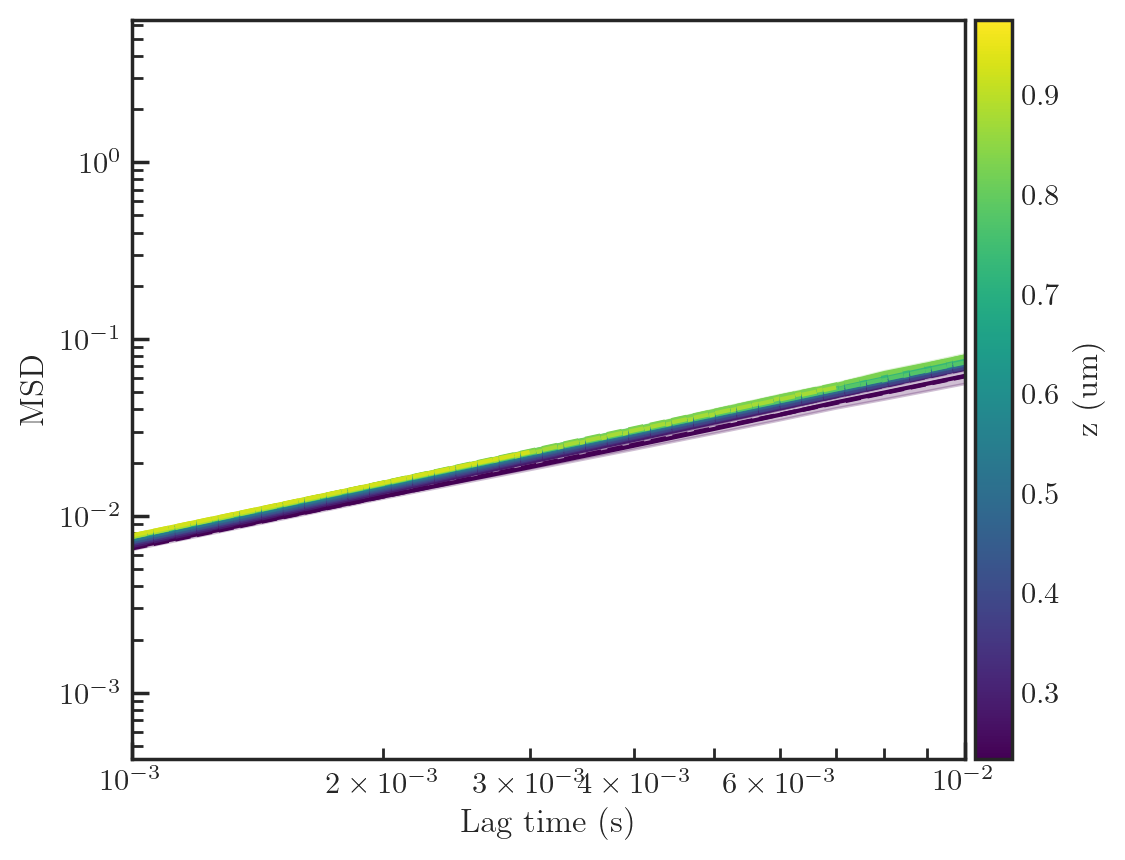

In [11]:
t_min, t_max = 1e-3, 1e-2

fig, ax, fit_results = plot_msd_curves_per_bin(
    bin_centers, taus_list, msd_mean, msd_sem,
    cmap_name="viridis",
    do_fit=True,
    t_min=t_min, t_max=t_max,            
    save_json_path="./D_per_height.json" 
)

plt.show()


Neat ! Now to plot Dy=f(z).

In [ ]:

def plot_diffusion(json_path):
    # Load data
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Extract and sort by z values
    z = sorted(map(float, data.keys()))
    D = [data[str(key)]["D"] for key in sorted(map(float, data.keys()))]
    stdD = [data[str(key)]["stdD"] for key in sorted(map(float, data.keys()))]

    # Plot
    plt.figure()
    plt.errorbar(z[:-1], D[:-1], yerr=stdD[:-1], fmt='o', capsize=4)
    plt.xlabel("$z$")
    plt.ylim(0, 5)
    plt.ylabel("$D_y (\mu \mathrm{m}^2.\mathrm{s}^{-1})$")
    plt.savefig("Dyfz.pdf", transparent = True)
    plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_9133/3192404968.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$D_y (\mu \mathrm{m}^2.\mathrm{s}^{-1})$")


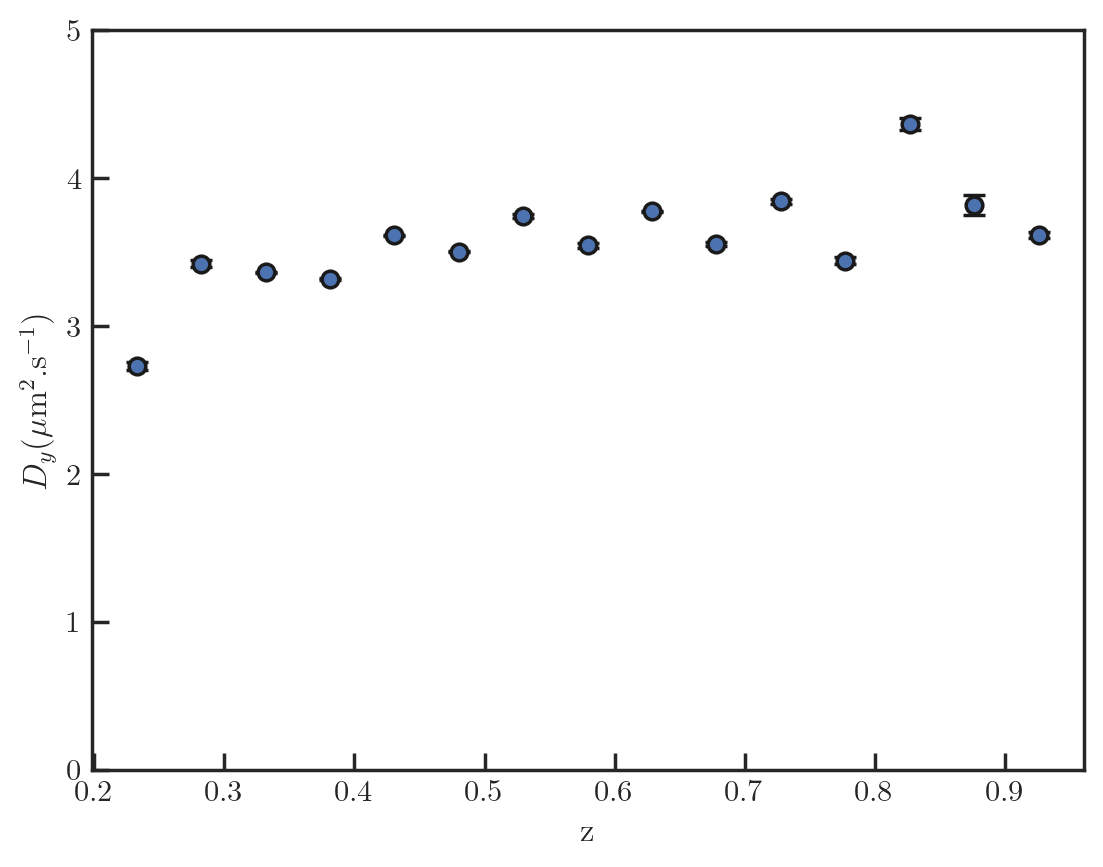

In [13]:
plot_diffusion("D_per_height.json")
